#Layoffs Dataset:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
var = pd.read_csv("layoffs.csv")
df = pd.DataFrame(var)
df

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Kraken,SF Bay Area,150.0,5/15/2026,NaN,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,5/15/2026
1,Innovaccer,SF Bay Area,340.0,5/14/2026,NaN,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,5/16/2026
2,Dune,"Oslo, Non-U.S.",NaN,5/14/2026,0.25,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79.0,Norway,5/15/2026
3,Gambling.com Group,"Dublin, Non-U.S.",NaN,5/14/2026,NaN,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276.0,Ireland,5/15/2026
4,Cisco,SF Bay Area,4000.0,5/13/2026,0.05,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2.0,United States,5/13/2026
...,...,...,...,...,...,...,...,...,...,...,...
4406,Service,Los Angeles,NaN,3/16/2020,1.00,Travel,https://techcrunch.com/2020/03/16/travel-savin...,Seed,5.1,United States,8/31/2020
4407,HopSkipDrive,Los Angeles,8.0,3/13/2020,0.10,Transportation,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,Unknown,45.0,United States,4/3/2020
4408,Panda Squad,SF Bay Area,6.0,3/13/2020,0.75,Consumer,https://twitter.com/danielsinger/status/123854...,Seed,1.0,United States,4/17/2020
4409,Tamara Mellon,Los Angeles,20.0,3/12/2020,0.40,Retail,https://layoffs.fyi/list/tamara-mellon/,Series C,90.0,United States,3/31/2020


In [3]:
df.shape
print()
df.columns
print()
df.info()
print()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4411 non-null   object 
 1   location             4410 non-null   object 
 2   total_laid_off       2889 non-null   float64
 3   date                 4411 non-null   object 
 4   percentage_laid_off  2777 non-null   float64
 5   industry             4409 non-null   object 
 6   source               4408 non-null   object 
 7   stage                4406 non-null   object 
 8   funds_raised         3902 non-null   float64
 9   country              4409 non-null   object 
 10  date_added           4411 non-null   object 
dtypes: float64(3), object(8)
memory usage: 379.2+ KB



,total_laid_off,percentage_laid_off,funds_raised
count,2889.000000,2777.000000,3902.000000
mean,316.433368,0.293337,858.274192
std,1200.433497,0.303406,4570.890341
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,175.000000
75%,200.000000,0.330000,482.750000
max,30000.000000,1.000000,121900.000000


In [4]:
df.columns = df.columns.str.strip()

In [11]:
df["date"] = pd.to_datetime(df["date"])
df["date_added"] = pd.to_datetime(df["date_added"])
df["total_laid_off"] = df["total_laid_off"].astype("int")
df["funds_raised"] = df["funds_raised"].astype("int")

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              4411 non-null   object        
 1   location             4410 non-null   object        
 2   total_laid_off       2889 non-null   float64       
 3   date                 4411 non-null   datetime64[ns]
 4   percentage_laid_off  2777 non-null   float64       
 5   industry             4409 non-null   object        
 6   source               4408 non-null   object        
 7   stage                4406 non-null   object        
 8   funds_raised         3902 non-null   float64       
 9   country              4409 non-null   object        
 10  date_added           4411 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 379.2+ KB


In [7]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1522
date                      0
percentage_laid_off    1634
industry                  2
source                    3
stage                     5
funds_raised            509
country                   2
date_added                0
dtype: int64

In [8]:
df["total_laid_off"]= df["total_laid_off"].fillna(316.4333679473866)
df["percentage_laid_off"] = df["percentage_laid_off"].fillna(0.2933372344256392)
df["funds_raised"] = df["funds_raised"].fillna(858.2741915684264)

In [9]:
df =df.fillna("unknown")
df

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Kraken,SF Bay Area,150.000000,2026-05-15,0.293337,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,2026-05-15
1,Innovaccer,SF Bay Area,340.000000,2026-05-14,0.293337,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,2026-05-16
2,Dune,"Oslo, Non-U.S.",316.433368,2026-05-14,0.250000,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79.0,Norway,2026-05-15
3,Gambling.com Group,"Dublin, Non-U.S.",316.433368,2026-05-14,0.293337,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276.0,Ireland,2026-05-15
4,Cisco,SF Bay Area,4000.000000,2026-05-13,0.050000,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2.0,United States,2026-05-13
...,...,...,...,...,...,...,...,...,...,...,...
4406,Service,Los Angeles,316.433368,2020-03-16,1.000000,Travel,https://techcrunch.com/2020/03/16/travel-savin...,Seed,5.1,United States,2020-08-31
4407,HopSkipDrive,Los Angeles,8.000000,2020-03-13,0.100000,Transportation,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,Unknown,45.0,United States,2020-04-03
4408,Panda Squad,SF Bay Area,6.000000,2020-03-13,0.750000,Consumer,https://twitter.com/danielsinger/status/123854...,Seed,1.0,United States,2020-04-17
4409,Tamara Mellon,Los Angeles,20.000000,2020-03-12,0.400000,Retail,https://layoffs.fyi/list/tamara-mellon/,Series C,90.0,United States,2020-03-31


In [10]:
df.isnull().sum()

company                0
location               0
total_laid_off         0
date                   0
percentage_laid_off    0
industry               0
source                 0
stage                  0
funds_raised           0
country                0
date_added             0
dtype: int64

In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4406    False
4407    False
4408    False
4409    False
4410    False
Length: 4411, dtype: bool

In [13]:
df.drop_duplicates()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Kraken,SF Bay Area,150,2026-05-15,0.293337,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134,United States,2026-05-15
1,Innovaccer,SF Bay Area,340,2026-05-14,0.293337,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379,United States,2026-05-16
2,Dune,"Oslo, Non-U.S.",316,2026-05-14,0.250000,Crypto,https://x.com/hagaetc/status/20549377718111928...,Series B,79,Norway,2026-05-15
3,Gambling.com Group,"Dublin, Non-U.S.",316,2026-05-14,0.293337,Other,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,276,Ireland,2026-05-15
4,Cisco,SF Bay Area,4000,2026-05-13,0.050000,Infrastructure,https://blogs.cisco.com/news/our-path-forward,Post-IPO,2,United States,2026-05-13
...,...,...,...,...,...,...,...,...,...,...,...
4406,Service,Los Angeles,316,2020-03-16,1.000000,Travel,https://techcrunch.com/2020/03/16/travel-savin...,Seed,5,United States,2020-08-31
4407,HopSkipDrive,Los Angeles,8,2020-03-13,0.100000,Transportation,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,Unknown,45,United States,2020-04-03
4408,Panda Squad,SF Bay Area,6,2020-03-13,0.750000,Consumer,https://twitter.com/danielsinger/status/123854...,Seed,1,United States,2020-04-17
4409,Tamara Mellon,Los Angeles,20,2020-03-12,0.400000,Retail,https://layoffs.fyi/list/tamara-mellon/,Series C,90,United States,2020-03-31


In [14]:
layoffs_by_companies = df.groupby("company")[ "total_laid_off"].sum()
layoffs_by_companies

company
 E Inc.             316
 F-Secure            70
 Included Health    316
#Paid                19
&Open                 9
                   ... 
reAlpha             316
tZero               316
theGist             316
uShip                65
xAI                 500
Name: total_laid_off, Length: 2909, dtype: int32

In [15]:
Top_layoffs_by_companies = layoffs_by_companies.sort_values(ascending=False).head(10)
Top_layoffs_by_companies

company
Amazon        60020
Intel         43747
Meta          36648
Oracle        32242
Microsoft     31951
Dell          24282
Cisco         18521
Salesforce    16841
Google        15909
Tesla         14816
Name: total_laid_off, dtype: int32

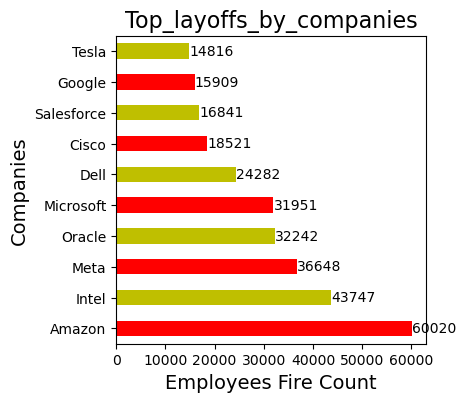

In [17]:
plt.figure(figsize = (4 , 4))
c = ["r" , "y"]
ax = Top_layoffs_by_companies.plot(kind="barh" , color = c)
ax.bar_label(ax.containers[0])



plt.title("Top_layoffs_by_companies" , fontsize = 16)
plt.xlabel("Employees Fire Count" , fontsize = 14)
plt.ylabel("Companies" , fontsize = 14)



plt.show()

In [18]:
# amazon intel or meta ki company nay sab say zayada employees ko lay offs kiya ha 

In [19]:
layoff_comp_percentage = df.groupby("company")["percentage_laid_off"].sum().sort_values(ascending=False).head(10)
layoff_comp_percentage

company
Amazon        4.753396
Google        4.753396
Microsoft     3.670047
Oracle        3.226710
Intel         2.990035
FrontRow      2.950000
Salesforce    2.495198
Expedia       2.456698
Meta          2.363361
TikTok        2.346698
Name: percentage_laid_off, dtype: float64

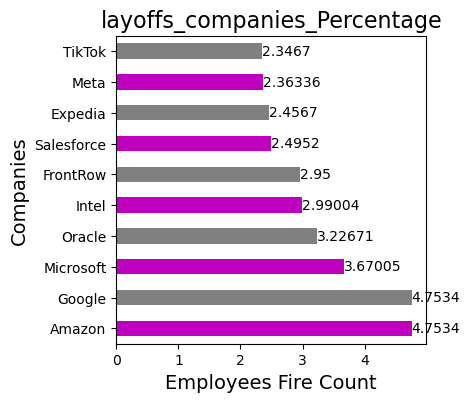

In [20]:
plt.figure(figsize = (4 , 4))
c = ["m" , "gray"]
ax = layoff_comp_percentage.plot(kind="barh" , color = c)
ax.bar_label(ax.containers[0])



plt.title("layoffs_companies_Percentage" , fontsize = 16)
plt.xlabel("Employees Fire Count" , fontsize = 14)
plt.ylabel("Companies" , fontsize = 14)



plt.show()

In [21]:
layoffs_by_industries = df.groupby("industry")["total_laid_off"].sum()
layoffs_by_industries

industry
AI                  5734
Aerospace           6316
Construction        8085
Consumer          128944
Crypto             37676
Data               30656
Education          37750
Energy             16516
Finance           120217
Fitness            14886
Food               79899
HR                 27849
Hardware          113541
Healthcare         77164
Infrastructure     36527
Legal               3584
Logistics          15749
Manufacturing      12124
Marketing          35691
Media              27689
Other             155063
Product             8855
Real Estate        42134
Recruiting         11156
Retail            142962
Sales              26345
Security           28570
Support            14485
Transportation     93494
Travel             35116
unknown              351
Name: total_laid_off, dtype: int32

In [22]:
Top_layoffs_by_industries = layoffs_by_industries.sort_values(ascending=False).head(10)
Top_layoffs_by_industries

industry
Other             155063
Retail            142962
Consumer          128944
Finance           120217
Hardware          113541
Transportation     93494
Food               79899
Healthcare         77164
Real Estate        42134
Education          37750
Name: total_laid_off, dtype: int32

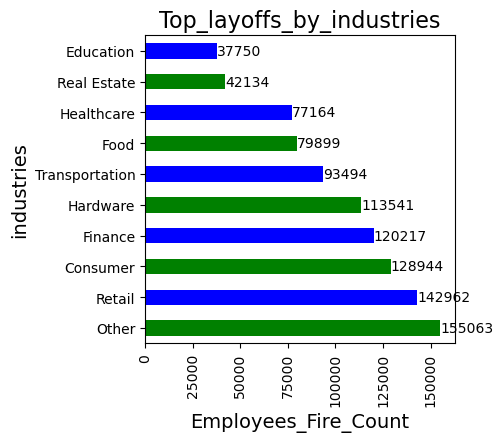

In [23]:
plt.figure(figsize = (4 , 4))
c = ["g" , "b"]
ax = Top_layoffs_by_industries.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])


plt.title("Top_layoffs_by_industries" , fontsize = 16)
plt.xlabel("Employees_Fire_Count" , fontsize = 14)
plt.ylabel("industries" , fontsize = 14)



plt.xticks(rotation=90)
plt.show()

In [24]:
# industries ma Other , Retail or Consumer nay sab say zayada employees ko layoff kiya ha

In [25]:
layoff_industry_percentage = df.groupby("industry")["percentage_laid_off"].sum().sort_values(ascending=False).head(10)
layoff_industry_percentage

industry
Finance           155.792342
Healthcare        107.413770
Retail            107.347201
Food               88.452002
Consumer           88.287213
Other              82.800456
Transportation     81.741026
Real Estate        52.690269
Education          51.806932
Marketing          50.635269
Name: percentage_laid_off, dtype: float64

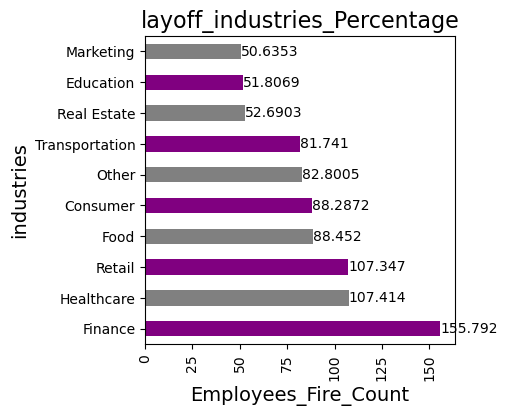

In [26]:
plt.figure(figsize = (4 , 4))
c = ["purple" , "gray"]
ax = layoff_industry_percentage.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])


plt.title("layoff_industries_Percentage" , fontsize = 16)
plt.xlabel("Employees_Fire_Count" , fontsize = 14)
plt.ylabel("industries" , fontsize = 14)



plt.xticks(rotation=90)
plt.show()

In [27]:
layoff_by_region = df.groupby("location")["total_laid_off"].sum()
layoff_by_region


location
Abuja, Non-U.S.        316
Accra, Non-U.S.        466
Ahmedabad, Non-U.S.    500
Alamosa                316
Albany                 371
                      ... 
Yangon, Non-U.S.       200
Yavne, Non-U.S.        100
Zug, Non-U.S.          632
Zurich, Non-U.S.       800
unknown                316
Name: total_laid_off, Length: 270, dtype: int32

In [28]:
Top_layoff_by_region = layoff_by_region.sort_values(ascending=False).head(10)
Top_layoff_by_region

location
SF Bay Area            425402
Seattle                127050
New York City           92540
Austin                  56149
Bengaluru, Non-U.S.     49203
Boston                  45669
London, Non-U.S.        40432
Los Angeles             35254
Sacramento              28846
Berlin, Non-U.S.        24890
Name: total_laid_off, dtype: int32

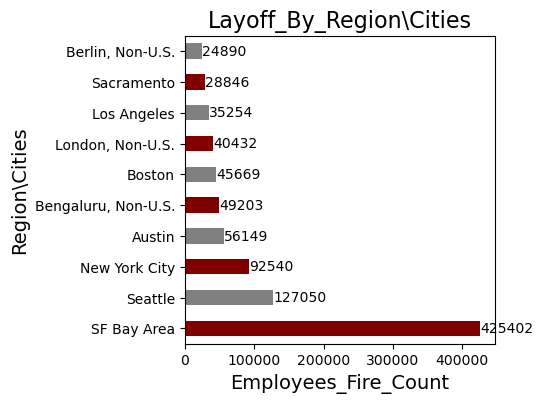

In [31]:
plt.figure(figsize = (4 , 4))
c = ["maroon" , "gray"]
ax = Top_layoff_by_region.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])



plt.title("Layoff_By_Region\Cities" , fontsize = 16)
plt.xlabel("Employees_Fire_Count", fontsize = 14)
plt.ylabel("Region\Cities" , fontsize = 14)




plt.show()


In [ ]:
# region or cities ma sab say zayada (SF Bay Area , Seattle or New York City) nay employees ko layoff kiya ha 

In [32]:
layoffs_by_stage = df.groupby("stage")["total_laid_off"].sum().sort_values(ascending=False)
layoffs_by_stage

stage
Post-IPO          674673
Unknown           172590
Acquired          116154
Series B           87465
Series C           77774
Series D           60690
Series A           44223
Series E           40798
Seed               33815
Series F           26487
Private Equity     22560
Series H           10393
Subsidiary         10382
Series G            7341
Series J            5016
Series I            3471
unknown             1296
Name: total_laid_off, dtype: int32

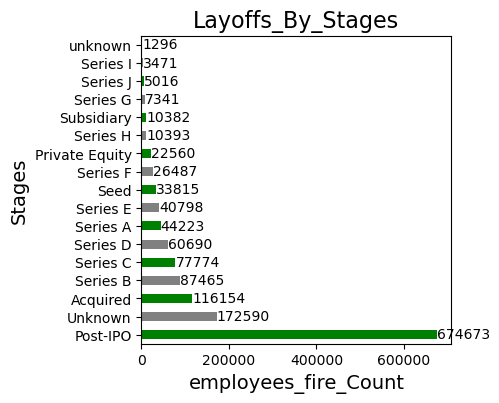

In [35]:
plt.figure(figsize=(4 , 4))
c = ["g" , "gray"]
ax = layoffs_by_stage.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])


plt.title("Layoffs_By_Stages", fontsize = 16)
plt.xlabel("employees_fire_Count", fontsize = 14)
plt.ylabel("Stages" , fontsize = 14)

plt.show()

In [ ]:
# stages say sab say zayada (Post-IPO , Unknown or Acquired) nay employees ko layoff kiya ha

In [36]:
layoff_by_country = df.groupby("country")["total_laid_off"].sum()
layoff_by_country

country
Argentina            639
Australia          18321
Austria             1542
Bahrain              316
Belgium              366
                   ...  
United Kingdom     44526
United States     973652
Uruguay              720
Vietnam              948
unknown              371
Name: total_laid_off, Length: 67, dtype: int32

In [37]:
Top_layoff_countries = layoff_by_country.sort_values(ascending=False).head(10)
Top_layoff_countries

country
United States     973652
India              89423
United Kingdom     44526
Germany            43115
Canada             30288
Israel             25191
Netherlands        24735
Sweden             23855
Australia          18321
Brazil             15731
Name: total_laid_off, dtype: int32

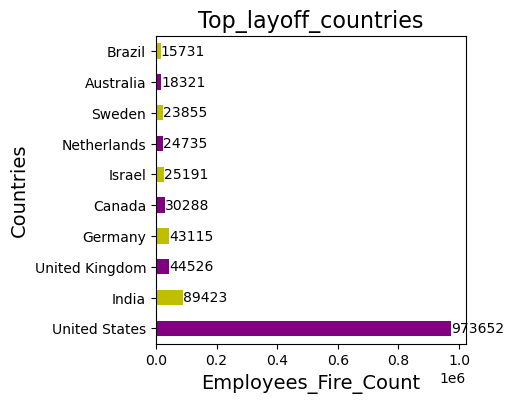

In [38]:
plt.figure(figsize=(4 , 4))
c = ["purple" , "y"]
ax = Top_layoff_countries.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])


plt.title("Top_layoff_countries" , fontsize = 16)
plt.xlabel("Employees_Fire_Count" , fontsize = 14)
plt.ylabel("Countries" , fontsize = 14)




plt.show()

In [ ]:
# countries say sab say zayada (United State , India) nay sab say zayada employees ko layoff kiya ha

In [39]:
companies_funds = df.groupby("company")[["total_laid_off" , "funds_raised"]].sum()
companies_funds

,total_laid_off,funds_raised
company,,
E Inc.,316,858
F-Secure,70,858
Included Health,316,272
#Paid,19,21
&Open,9,35
...,...,...
reAlpha,316,229
tZero,316,472
theGist,316,7


In [40]:
Top_companies_Funds = companies_funds.sort_values(by=["total_laid_off", "funds_raised"] , ascending=False).head(10)
Top_companies_Funds

,total_laid_off,funds_raised
company,,
Amazon,60020,57996
Intel,43747,132
Meta,36648,312000
Oracle,32242,9438
Microsoft,31951,16
Dell,24282,4290
Cisco,18521,12
Salesforce,16841,845
Google,15909,442


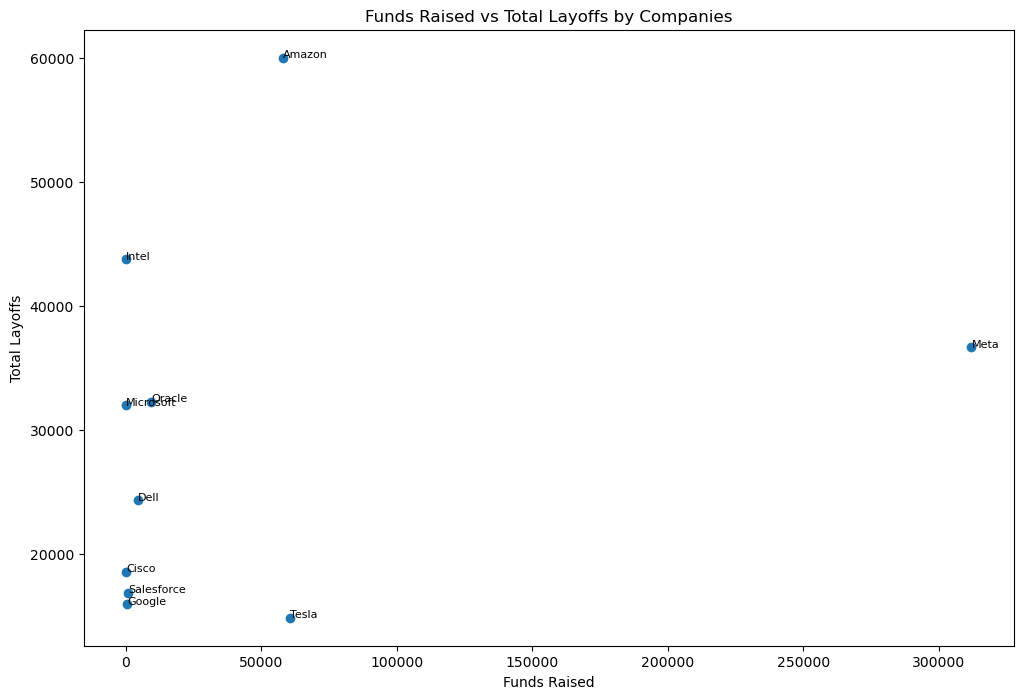

In [180]:
plt.figure(figsize=(12,8))

plt.scatter(
    Top_companies_Funds["funds_raised"],
    Top_companies_Funds["total_laid_off"]
)

# Company names add karna
for company, row in Top_companies_Funds.iterrows():
    plt.text(
        row["funds_raised"],
        row["total_laid_off"],
        company,
        fontsize=8
    )

plt.xlabel("Funds Raised")
plt.ylabel("Total Layoffs")
plt.title("Funds Raised vs Total Layoffs by Companies")

plt.show()

In [ ]:
# companies ma Meta nay sab say zayada fund diya ha or (36648) employees ko layoff kiya ha 
# companies ma sab say kam fund (Google , Salesorce or Cisco) nay diya ha orsay say kam employees ko layoff bhi inho nay kiya ha

In [41]:
industry_count = df["industry"].value_counts(ascending=False).head(10)
industry_count

industry
Finance           524
Retail            352
Healthcare        327
Other             300
Consumer          299
Transportation    270
Food              249
Marketing         212
Real Estate       165
Crypto            164
Name: count, dtype: int64

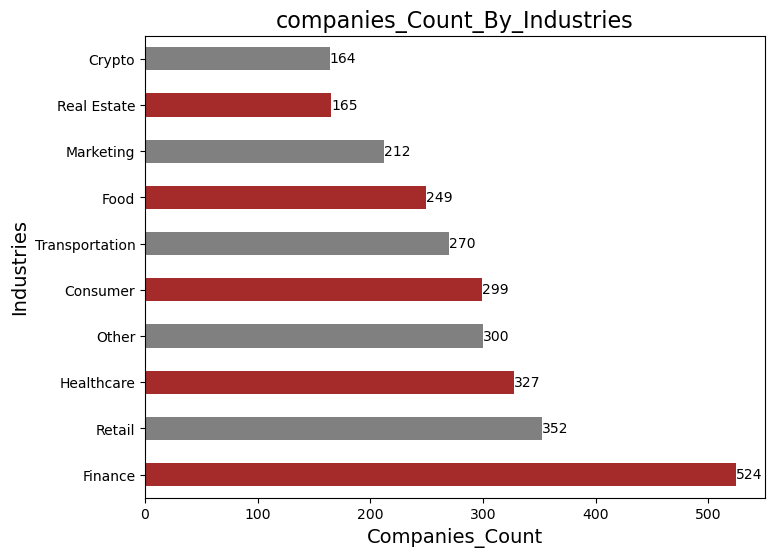

In [42]:
plt.figure(figsize=(8 , 6))
c = ["brown" , "gray"]
ax = industry_count.plot(kind="barh" , color = c)
plt.bar_label(ax.containers[0])


plt.title("companies_Count_By_Industries" , fontsize = 16)
plt.xlabel("Companies_Count" , fontsize = 14)
plt.ylabel("Industries" , fontsize = 14)


plt.show()

In [ ]:
# industries ma sab say zayada companies (Finance , Retail , Healthcare) ma registered han 

In [43]:
industry_funds = df.groupby("industry")[["total_laid_off" , "funds_raised"]].sum()
industry_funds

,total_laid_off,funds_raised
industry,,
AI,5734,35438
Aerospace,6316,11037
Construction,8085,9509
Consumer,128944,619656
Crypto,37676,70687
Data,30656,62538
Education,37750,67266
Energy,16516,47270
Finance,120217,259206


In [44]:
Top_industry_funds = industry_funds.sort_values(by=["total_laid_off" , "funds_raised"] , ascending=False).head(10)
Top_industry_funds

,total_laid_off,funds_raised
industry,,
Other,155063,129241
Retail,142962,273808
Consumer,128944,619656
Finance,120217,259206
Hardware,113541,78477
Transportation,93494,627101
Food,79899,190700
Healthcare,77164,151006
Real Estate,42134,151964


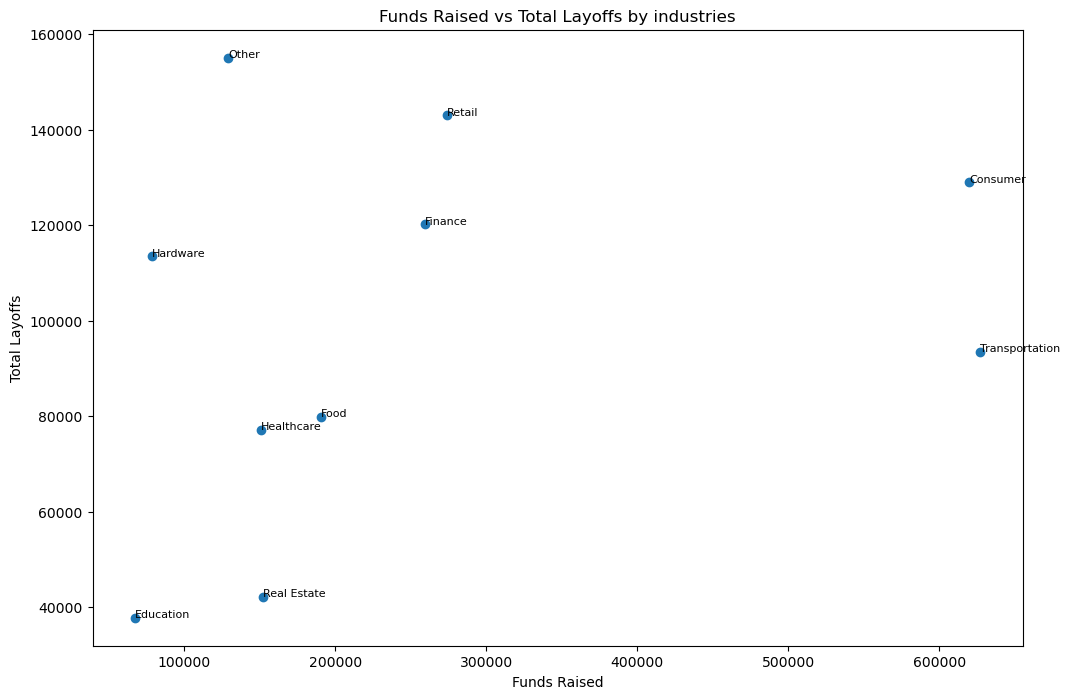

In [45]:
plt.figure(figsize=(12,8))

plt.scatter(
    Top_industry_funds["funds_raised"],
    Top_industry_funds["total_laid_off"]
)

# industries names add karna
for industry, row in Top_industry_funds.iterrows():
    plt.text(
        row["funds_raised"],
        row["total_laid_off"],
        industry,
        fontsize=8
    )

plt.xlabel("Funds Raised")
plt.ylabel("Total Layoffs")
plt.title("Funds Raised vs Total Layoffs by industries")

plt.show()

# sab say zayada fund Transportation or consumer industries nay diya ha 
# Transportation industry nay  (93494) employees ko layoff kiya ha 
# consumer industry nay (128944) employees ko lay off kiya ha
# other indusry nay (129241) fund diya ha or (155063) employees ko lay off kiya ha 
# sab say kam fund Education or Hardware ki industry nay diya ha

In [46]:
company_dates = df.groupby("company")["date"].min()

company_dates

company
 E Inc.            2022-12-16
 F-Secure          2023-10-25
 Included Health   2022-07-25
#Paid              2023-01-27
&Open              2022-11-17
                      ...    
reAlpha            2026-05-06
tZero              2020-07-30
theGist            2025-09-03
uShip              2020-03-31
xAI                2025-09-12
Name: date, Length: 2909, dtype: datetime64[ns]